# <span style="color:darkblue"> Lecture 12b - Random Assignment </span>

<font size = "5">



# <span style="color:darkblue"> I. Import Libraries and Data </span>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
carfeatures = pd.read_csv("data_raw/features.csv")

# <span style="color:darkblue"> II. Random Assignment </span>

<font size = "5">

Random assignment is crucial for scientific progress ...

- The basis for medical trials
- Also used in engineering, the natural sciences and <br>
  social sciences (economics, political science, etc.)


In [3]:
# "list_status" is a list with "treatment/control" arms
# "prop_status" is the proportion in the treatment and control arms
# "size_dataset" is how many rows are contained

list_status  = ["Treatment","Control"]
prop_status  = [0.4,0.6]
size_dataset = len(carfeatures)

<font size = "5">
Random assignment


In [4]:
# The "np.random.choice" will create a vector with the status
# We will save this to a column in "carfeatures"
# Note: (i) We can always split the arguments of a function in multiple lines
#           to make it easier to read

carfeatures["status"] = np.random.choice(list_status,
                                         size = size_dataset,
                                         p = prop_status)

display(carfeatures)

,mpg,cylinders,displacement,horsepower,weight,acceleration,vehicle_id,status
0,18.0,8,307,130,3504,12.0,C-1689780,Control
1,15.0,8,350,165,3693,11.5,B-1689791,Treatment
2,18.0,8,318,150,3436,11.0,P-1689802,Control
3,16.0,8,304,150,3433,12.0,A-1689813,Treatment
4,17.0,8,302,140,3449,10.5,F-1689824,Control
...,...,...,...,...,...,...,...,...
393,27.0,4,140,86,2790,15.6,F-1694103,Control
394,44.0,4,97,52,2130,24.6,V-1694114,Control
395,32.0,4,135,84,2295,11.6,D-1694125,Control
396,28.0,4,120,79,2625,18.6,F-1694136,Control


<font size = "5">

Compute frequencies by status

In [5]:
# The command "pd.crosstab" computes frequencies
# If we add the option "normalize" it will compute proportions
# Note: The default assignment is done randomly without replacement
#       which means that the proportions are approximately the same   
#       (but not equal) to "prop_status"

frequency_table   = pd.crosstab(index = carfeatures["status"], columns = "Frequency")
proportions_table = pd.crosstab(index = carfeatures["status"],
                                columns = "Frequency",
                                normalize = True)

display(frequency_table)
display(proportions_table)


col_0,Frequency
status,
Control,231
Treatment,167


col_0,Frequency
status,
Control,0.580402
Treatment,0.419598


<font size = "5">

Query with string conditions

In [6]:
# When you have queries for text variables, it's important
# to use outer ' ' single quotations
# and inner double quotations.

data_treated = carfeatures.query('status == "Treatment" ')
data_control = carfeatures.query('status == "Control" ')

<font size = "5">

Treated/control should be similar

- This is the key principle of random assignment
- We can check the summary statistics

In [7]:
# The count is different because we assigned different proportions
# All other sumary statistics are approximately the same
# They are not identical because the assignment is random

display(data_treated.describe())
display(data_control.describe())

,mpg,cylinders,displacement,weight,acceleration
count,167.000000,167.000000,167.000000,167.000000,167.000000
mean,23.080838,5.419162,192.005988,2985.934132,15.572455
std,7.785598,1.669461,103.146901,824.804447,2.778308
min,9.000000,3.000000,70.000000,1649.000000,8.500000
25%,17.000000,4.000000,99.000000,2272.000000,14.000000
50%,22.000000,4.000000,145.000000,2875.000000,15.500000
75%,27.450000,6.000000,254.000000,3631.000000,17.150000
max,46.600000,8.000000,440.000000,4955.000000,24.800000


,mpg,cylinders,displacement,weight,acceleration
count,231.000000,231.000000,231.000000,231.000000,231.000000
mean,23.828139,5.480519,194.454545,2959.212121,15.564935
std,7.839772,1.726598,105.283577,864.028901,2.748728
min,10.000000,3.000000,68.000000,1613.000000,8.000000
25%,17.600000,4.000000,105.000000,2206.000000,13.700000
50%,23.000000,4.000000,151.000000,2735.000000,15.500000
75%,29.900000,8.000000,284.500000,3546.500000,17.150000
max,44.600000,8.000000,455.000000,5140.000000,24.600000


<font size = "5">

Exercises:

Import the dataset "data_quiz/fifa23_players_basic.csv"

- It's a dataset on professional soccer players
- Rows correspond to players (18,539)
- Columns contain attributes of players (32)
- Try to view the dataset before starting

<font size = "5">

Try it yourself!

<font size = "3">

- Create ``` list_status = [0,1]```
- Create ``` list_prob = [0.5, 0.5]```
- Create a new variable $n$ with the number of rows of the dataset
- Use 
```python
    np.random.choice(list_status,
                     size = n,
                     p = list_prob)
```
$\qquad$ to create a new column called "status" <br>
$\qquad$ which randomly assigns each row to "0" or "1" <br>
$\qquad$ with equal probability
- Use .query() to subset all observations with status == 0.<br>
store it in a new dataset called "data0"
- Use .query() to subset all observations with status == 1.<br>
store it in a new dataset called "data1"



In [ ]:
# Write your own code

players = pd.read_csv("data_raw/fifa23_players_basic.csv")

In [14]:
list_status  = ["0","1"]
list_prob  = [0.5,0.5]
size_dataset = len(players)

players["status"] = np.random.choice(list_status,
                 size = len(players),
                 p = list_prob)

data0 = players.query('status == "0" ')
data1 = players.query('status == "1" ')

display(data0.describe())
display(data1.describe())

,Overall,Potential,Value(in Euro),Age,Height(in cm),Weight(in kg),TotalStats,BaseStats,Wage(in Euro),Release Clause,Joined On,Weak Foot Rating,Skill Moves,International Reputation
count,9220.000000,9220.000000,9.220000e+03,9220.000000,9220.000000,9220.000000,9220.000000,9220.000000,9220.000000,9.220000e+03,9220.000000,9220.000000,9220.00000,9220.000000
mean,65.851627,71.041215,2.937852e+06,25.203796,181.560304,75.172451,1601.792950,357.944794,8840.770065,5.184102e+06,2020.371475,2.945879,2.36269,1.087310
std,6.805186,6.195537,7.880845e+06,4.703303,6.855817,6.984788,273.473186,39.680715,19747.596320,1.493790e+07,2.056019,0.674324,0.77079,0.363588
min,47.000000,50.000000,0.000000e+00,16.000000,156.000000,49.000000,759.000000,224.000000,0.000000,0.000000e+00,2004.000000,1.000000,1.00000,1.000000
25%,62.000000,67.000000,5.000000e+05,21.000000,177.000000,70.000000,1470.750000,331.000000,1000.000000,6.830000e+05,2020.000000,3.000000,2.00000,1.000000
50%,66.000000,71.000000,1.000000e+06,25.000000,182.000000,75.000000,1640.000000,358.000000,3000.000000,1.500000e+06,2021.000000,3.000000,2.00000,1.000000
75%,70.000000,75.000000,2.000000e+06,29.000000,186.000000,80.000000,1786.000000,385.000000,7250.000000,3.400000e+06,2022.000000,3.000000,3.00000,1.000000
max,91.000000,94.000000,1.480000e+08,44.000000,206.000000,105.000000,2312.000000,502.000000,420000.000000,3.034000e+08,2022.000000,5.000000,5.00000,5.000000


,Overall,Potential,Value(in Euro),Age,Height(in cm),Weight(in kg),TotalStats,BaseStats,Wage(in Euro),Release Clause,Joined On,Weak Foot Rating,Skill Moves,International Reputation
count,9319.000000,9319.000000,9.319000e+03,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9319.000000,9.319000e+03,9319.000000,9319.000000,9319.000000,9319.000000
mean,65.852452,70.992381,2.813733e+06,25.276639,181.541474,75.175341,1602.432772,357.947634,8808.477304,4.980362e+06,2020.363451,2.946990,2.369568,1.085310
std,6.772022,6.190460,7.383886e+06,4.732792,6.860707,7.042351,272.864561,39.578421,19173.332847,1.440425e+07,2.056823,0.673273,0.774071,0.353922
min,47.000000,48.000000,0.000000e+00,16.000000,155.000000,53.000000,777.000000,230.000000,0.000000,0.000000e+00,2002.000000,1.000000,1.000000,1.000000
25%,62.000000,67.000000,4.750000e+05,22.000000,177.000000,70.000000,1470.000000,331.000000,1000.000000,6.560000e+05,2020.000000,3.000000,2.000000,1.000000
50%,66.000000,71.000000,9.750000e+05,25.000000,182.000000,75.000000,1640.000000,358.000000,3000.000000,1.500000e+06,2021.000000,3.000000,2.000000,1.000000
75%,70.000000,75.000000,2.000000e+06,29.000000,186.000000,80.000000,1786.000000,385.000000,8000.000000,3.300000e+06,2022.000000,3.000000,3.000000,1.000000
max,91.000000,95.000000,1.905000e+08,42.000000,206.000000,104.000000,2303.000000,501.000000,450000.000000,3.667000e+08,2022.000000,5.000000,5.000000,5.000000


<font size = "5">

Try it yourself!

<font size = "3">

- This question requires the two datasets you created in the previous question
- Display the distribution of "Age" for "data0" and "data1"
- Use the "alpha" option to make the graphs semitransparent
- You will need to add a legend, label the axes, and the title

Note: The goal of this question is to illustrate that random <br>
assignment produces very similar distributions between two groups

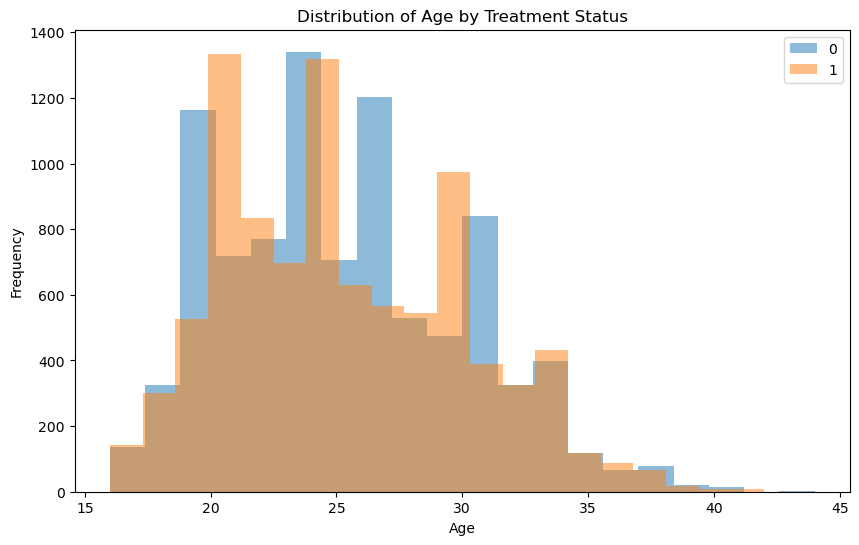

In [ ]:
# Write your own code

# display distributions of age by treatment status - annotated
plt.figure(figsize=(10,6)) # Set the figure size
plt.hist(data0["Age"], alpha=0.5, label='0', bins=20) # Histogram for treatment group
plt.hist(data1["Age"], alpha=0.5, label='1', bins=20) # Histogram for control group
plt.xlabel('Age') # X-axis label
plt.ylabel('Frequency') # Y-axis label
plt.title('Distribution of Age by Treatment Status') # Title
plt.legend() # Legend
plt.show() # Show the plot




# <span style="color:darkblue"> III. Further information </span>

<font size = "5">

https://discovery.cs.illinois.edu/learn/Basics-of-Data-Science-with-Python/Experimental-Design-and-Blocking/